In [49]:
import pandas as pd
import numpy as np

In [50]:
df = pd.read_csv('jamb_exam_results.csv', na_values=['', ' ', 'NULL', 'null'])

In [51]:
df.isna().sum()

JAMB_Score                        0
Study_Hours_Per_Week              0
Attendance_Rate                   0
Teacher_Quality                   0
Distance_To_School                0
School_Type                       0
School_Location                   0
Extra_Tutorials                   0
Access_To_Learning_Materials      0
Parent_Involvement                0
IT_Knowledge                      0
Student_ID                        0
Age                               0
Gender                            0
Socioeconomic_Status              0
Parent_Education_Level          891
Assignments_Completed             0
dtype: int64

In [52]:
df

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,183,20,74,2,10.6,Public,Urban,Yes,No,Low,Low,4996,16,Male,Medium,Primary,2
4996,179,0,80,2,20.0,Public,Rural,No,Yes,Medium,Medium,4997,22,Male,Low,Secondary,1
4997,261,17,89,3,11.3,Public,Urban,No,No,Low,High,4998,18,Male,Medium,Primary,3
4998,183,15,96,2,15.9,Public,Rural,No,No,Low,Medium,4999,18,Male,Medium,Secondary,1


In [53]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.fillna(0)

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
df = df.drop('student_id', axis=1)
X = df.drop('jamb_score', axis=1)
y = df['jamb_score']

In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1)

In [56]:
dv = DictVectorizer(sparse=True)

# Преобразуем данные в словари
train_dicts = X_train.to_dict(orient='records')
val_dicts = X_val.to_dict(orient='records')
test_dicts = X_test.to_dict(orient='records')

# Применяем DictVectorizer
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

In [57]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=1)
model.fit(X_train, y_train)
features = dv.get_feature_names_out()

In [59]:
features[model.tree_.feature[0]]

'study_hours_per_week'

In [60]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [61]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_val, y_pred)

43.157758977963624

42.13 - ближайший

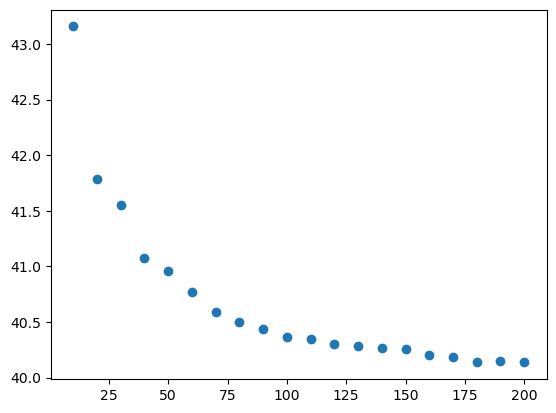

In [62]:
from matplotlib import pyplot as plt
rmse = []
x_axis = []
for i in range(10, 201, 10):
    model = RandomForestRegressor(n_estimators=i, random_state=1, n_jobs=-1)
    model.fit(X_train, y_train)
    Y_pred = model.predict(X_val)
    rmse.append(round(root_mean_squared_error(y_val, Y_pred), 3))
    x_axis.append(i)
plt.figure()
plt.scatter(x_axis, rmse)

чето ближе к 200

In [63]:
mean_rmse = {}
depth = [10, 15, 20, 25]

for i in depth:
    rmse = []
    for j in range(10, 201, 10):
        model = RandomForestRegressor(n_estimators=j, max_depth=i, random_state=1, n_jobs=-1)
        model.fit(X_train, y_train)
        Y_pred = model.predict(X_val)
        rmse.append(round(root_mean_squared_error(y_val, Y_pred), 3))
    mean_rmse[i] = np.mean(rmse)

In [64]:
mean_rmse

{10: np.float64(40.1379),
 15: np.float64(40.64395),
 20: np.float64(40.60980000000001),
 25: np.float64(40.68765)}

In [65]:
model = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)
importances = model.feature_importances_
names = dv.get_feature_names_out()
max_importance = max(importances)
for i in range(0, len(importances)):
    if importances[i] == max_importance:
        print(names[i])
        break

study_hours_per_week


1)study_hours_per_week

2)42.13

3)200

4)10

5)study_hours_per_week